Quantify the amount of error from gluing/polishing that would kill toliman. 

In [2]:
import dLuxToliman as dlT
import dLux.utils as dlu
import dLux as dl
import zodiax as zdx

from matplotlib import pyplot as plt
from matplotlib.colors import PowerNorm, CenteredNorm

import jax.numpy as jnp
import jax.random as jr
import jax

jax.config.update("jax_enable_x64", True)

from src.PhaseRetrieval import jax_0_4_24_logpmf

Basis model

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/var/folders/2j/vdv93b7508qfh_tr2nx03dh80000gp/T/ipykernel_25564/1174756306.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Toliman $\sqrt{PSF}$")


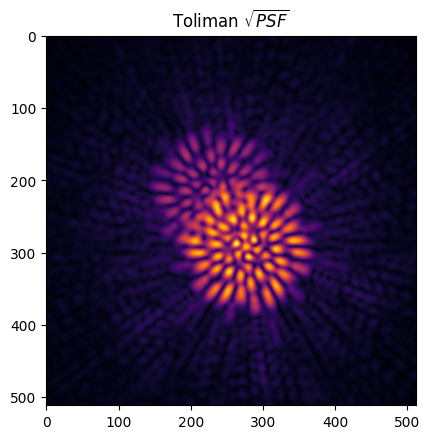

TolimanOpticalSystem(
  wf_npixels=256,
  diameter=0.125,
  layers={
    'aberr':
    BasisLayer(basis=f64[8,256,256], coefficients=f64[8], as_phase=False),
    'aperture':
    TransmissiveLayer(transmission=f64[256,256], normalise=True),
    'pupil':
    AberratedLayer(opd=f64[256,256], phase=None)
  },
  psf_npixels=128,
  oversample=4,
  psf_pixel_scale=0.375
)


In [3]:
osys = dlT.TolimanOpticalSystem(psf_npixels=128)  # creating Toliman optical system
source = dlT.AlphaCen(
    n_wavels=3, separation=8, position_angle=30
)  # creating Alpha Centauri source

# add layer to hold aberrations
coords = dlu.pixel_coords(npixels=osys.wf_npixels, diameter=osys.diameter)
Nnoll = 11  # from defocus to Nnoll zernike indices
zernike_indicies = jnp.arange(4, Nnoll + 1)
basis = dlu.zernike_basis(
    js=zernike_indicies, coordinates=coords, diameter=osys.diameter
)

osys_aberr = osys.insert_layer(
    layer=(
        "aberr",
        dl.BasisLayer(basis=basis, coefficients=jnp.zeros(len(zernike_indicies))),
    ),
    index=0,
)
psf = osys.model(source)  # running optical simulation

# plotting
plt.imshow(psf, norm=PowerNorm(0.5), cmap="inferno")
plt.title("Toliman $\sqrt{PSF}$")
plt.show()

print(osys_aberr)

Add aberrations

PV = 1370.18nm


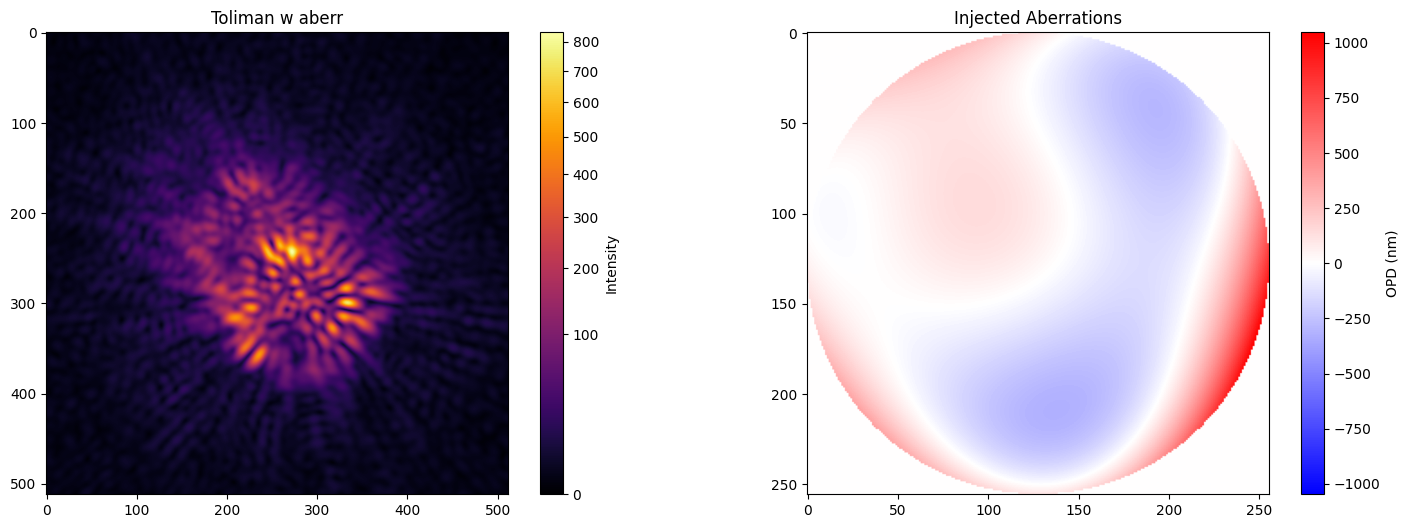

In [4]:
spherical_only = False
RMS_WFE = 200e-9  # 10 nm RMS WFE
if spherical_only:
    osys_aberr = osys_aberr.set(
        "aberr.coefficients", jnp.zeros(len(zernike_indicies)).at[-1].set(RMS_WFE)
    )

else:
    # Low-order (excluding Noll <= 4)
    # with the assumption that they could be mitigated with detector movement
    # evenly distributing the WFE across the remaining modes
    coeffs = jnp.ones(len(zernike_indicies)) * (
        RMS_WFE / jnp.sqrt(len(zernike_indicies))
    )
    osys_aberr = osys_aberr.set("aberr.coefficients", coeffs)

psf = osys_aberr.model(source)
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.imshow(psf, norm=PowerNorm(0.5), cmap="inferno")
plt.title("Toliman w aberr")
plt.colorbar(label="Intensity")
plt.subplot(1, 2, 2)
opd = osys_aberr.aberr.eval_basis()
print("PV = {:.2f}nm".format(jnp.abs(opd.max() - opd.min()) * 1e9))
plt.imshow(opd * 1e9, cmap="bwr", norm=CenteredNorm())
plt.title("Injected Aberrations")
plt.colorbar(label="OPD (nm)")

CRLB

In [6]:
model = dl.Telescope(optics=osys_aberr, source=source)

In [7]:
# define likelihood function for poisson noise
def poiss_loglike(model, data):
    return jax_0_4_24_logpmf(k=data, mu=model.model()).sum()


params = [
    "source.separation",
    "source.position_angle",
    "source.contrast",
    "aberr.coefficients",
    # "psf_pixel_scale",
]
dummy_data = jr.poisson(jr.PRNGKey(0), model.model())
cov = zdx.self_covariance_matrix(
    pytree=model, parameters=params, loglike_fn=zdx.bayes.poiss_loglike
)

print("CRLB separation (uas): {:.2f}".format(jnp.sqrt(cov[0, 0]) * 1e6))

CRLB separation (uas): 670.57


In [8]:
source

AlphaCen(
  separation=8,
  position_angle=30,
  x_position=0.0,
  y_position=0.0,
  log_flux=6.832,
  contrast=3.37,
  bandpass=(530, 640),
  weights=f64[2,3],
  wavelengths=f64[3]
)

Note separation is in as 

Loop it, spherical

In [9]:
RMS_WFE = jnp.linspace(0, 200e-9, 20)  # nm
PVS, CRLBS = [], []
OPD_ARRS, PSF_ARRS = [], []

for rms in RMS_WFE:
    osys_aberr = osys_aberr.set(
        "aberr.coefficients", jnp.zeros(len(zernike_indicies)).at[0].set(rms)
    )

    model = dl.Telescope(optics=osys_aberr, source=source)
    cov = zdx.self_covariance_matrix(
        pytree=model, parameters=params, loglike_fn=zdx.bayes.poiss_loglike
    )

    opd = osys_aberr.aberr.eval_basis()
    pv = jnp.abs(opd.max() - opd.min())

    CRLBS.append(jnp.sqrt(cov[0, 0]))
    PVS.append(pv)

    OPD_ARRS.append(opd)
    PSF_ARRS.append(osys_aberr.model(source))

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/var/folders/2j/vdv93b7508qfh_tr2nx03dh80000gp/T/ipykernel_25564/3530104304.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("CRLB on Binary Separation (${\mu}$as)", fontsize=12)
/var/folders/2j/vdv93b7508qfh_tr2nx03dh80000gp/T/ipykernel_25564/3530104304.py:36: SyntaxWarning: invalid escape sequence '\m'
  "Observation Time (min) to reach 1$\mu$as precision @0.1s exposure",


Text(0, 0.5, 'Observation Time (min) to reach 1$\\mu$as precision @0.1s exposure')

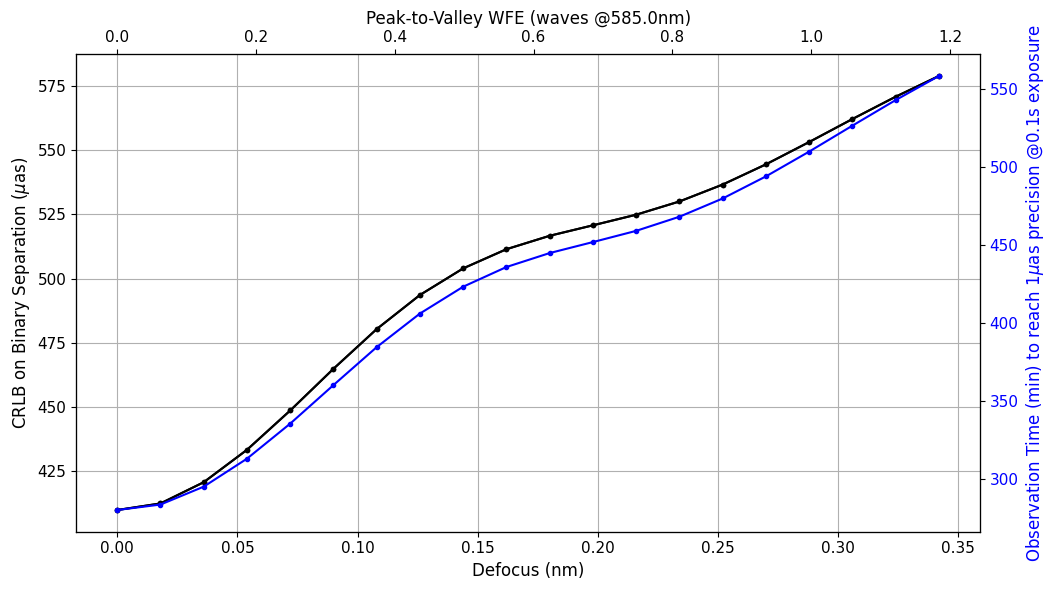

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(
    RMS_WFE / (source.wavelengths[1] * 1e-9), jnp.array(CRLBS) * 1e6, "k.-"
)  # mas -> microarcseconds
plt.grid()
plt.xlabel(
    "Defocus (nm)",
    fontsize=12,
)
plt.gca().tick_params(axis="x", labelsize=11)
plt.gca().tick_params(axis="y", labelsize=11)
plt.ylabel("CRLB on Binary Separation (${\mu}$as)", fontsize=12)
ax1 = plt.gca()

ax2 = ax1.twiny()
ax2.plot(
    jnp.asarray(PVS) / (source.wavelengths[1] * 1e-9), jnp.array(CRLBS) * 1e6, "k.-"
)
ax2.set_xlabel(
    "Peak-to-Valley WFE (waves @{}nm)".format(source.wavelengths[1]),
    color="black",
    fontsize=12,
)
ax2.tick_params(axis="x", labelsize=11, labelcolor="black")
plt.tight_layout()


# total integration time
exp_time = 0.1  # s
N = ((jnp.array(CRLBS) * 1e6) / 1) ** 2
IT = N * exp_time * 1 / 60
ax3 = ax1.twinx()
ax3.plot(RMS_WFE / (source.wavelengths[1] * 1e-9), IT, "b.-")
ax3.tick_params(axis="y", labelsize=11, labelcolor="blue")
ax3.set_ylabel(
    "Observation Time (min) to reach 1$\mu$as precision @0.1s exposure",
    color="blue",
    fontsize=12,
)
# ax3.axhline(10, color="blue", linestyle="--")

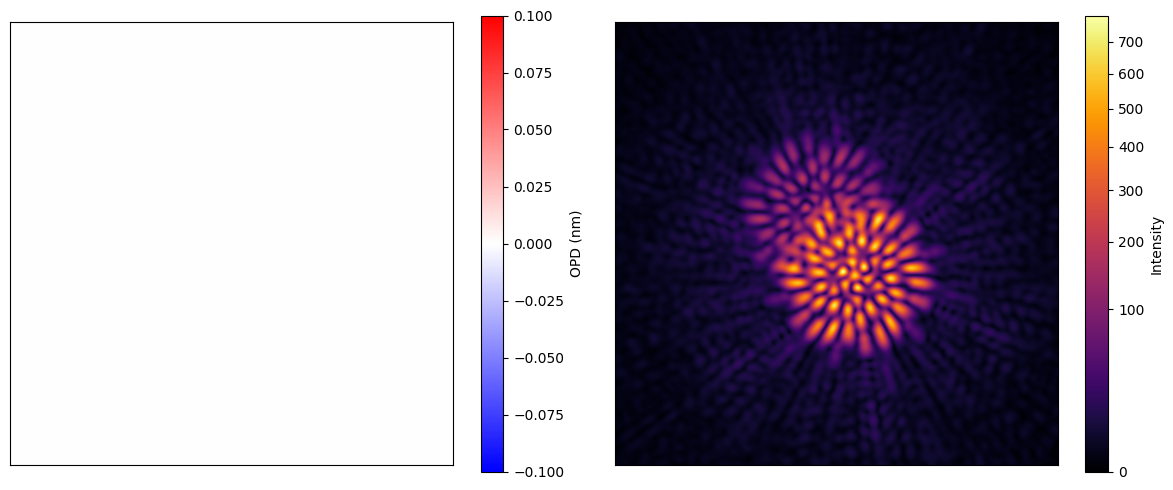

In [11]:
idx = 0
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(OPD_ARRS[idx] * 1e9, cmap="bwr", norm=CenteredNorm())
plt.colorbar(label="OPD (nm)")
plt.xticks([])
plt.yticks([])
plt.subplot(1, 2, 2)
plt.imshow(PSF_ARRS[idx], norm=PowerNorm(0.5), cmap="inferno")
plt.colorbar(label="Intensity")
plt.xticks([])
plt.yticks([])
plt.tight_layout()

Loop it, LE

In [245]:
RMS_WFE = jnp.linspace(0, 200e-9, 20)  # nm
PVS, CRLBS = [], []
OPD_ARRS, PSF_ARRS = [], []

for rms in RMS_WFE:
    # uniform, excluding defocus
    coeffs = jnp.zeros(len(zernike_indicies)) + (
        rms / jnp.sqrt(len(zernike_indicies) - 1)
    )
    coeffs = coeffs.at[0].set(0)  # set defocus to zero
    osys_aberr = osys_aberr.set("aberr.coefficients", coeffs)

    model = dl.Telescope(optics=osys_aberr, source=source)
    cov = zdx.self_covariance_matrix(
        pytree=model, parameters=params, loglike_fn=zdx.bayes.poiss_loglike
    )

    opd = osys_aberr.aberr.eval_basis()
    pv = jnp.abs(opd.max() - opd.min())

    CRLBS.append(jnp.sqrt(cov[0, 0]))
    PVS.append(pv)

    OPD_ARRS.append(opd)
    PSF_ARRS.append(osys_aberr.model(source))

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/var/folders/2j/vdv93b7508qfh_tr2nx03dh80000gp/T/ipykernel_35411/3912206184.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("CRLB on Binary Separation (${\mu}$as)", fontsize=12)
/var/folders/2j/vdv93b7508qfh_tr2nx03dh80000gp/T/ipykernel_35411/3912206184.py:36: SyntaxWarning: invalid escape sequence '\m'
  "Observation Time (min) to reach 1$\mu$as precision @0.1s exposure",


Text(0, 0.5, 'Observation Time (min) to reach 1$\\mu$as precision @0.1s exposure')

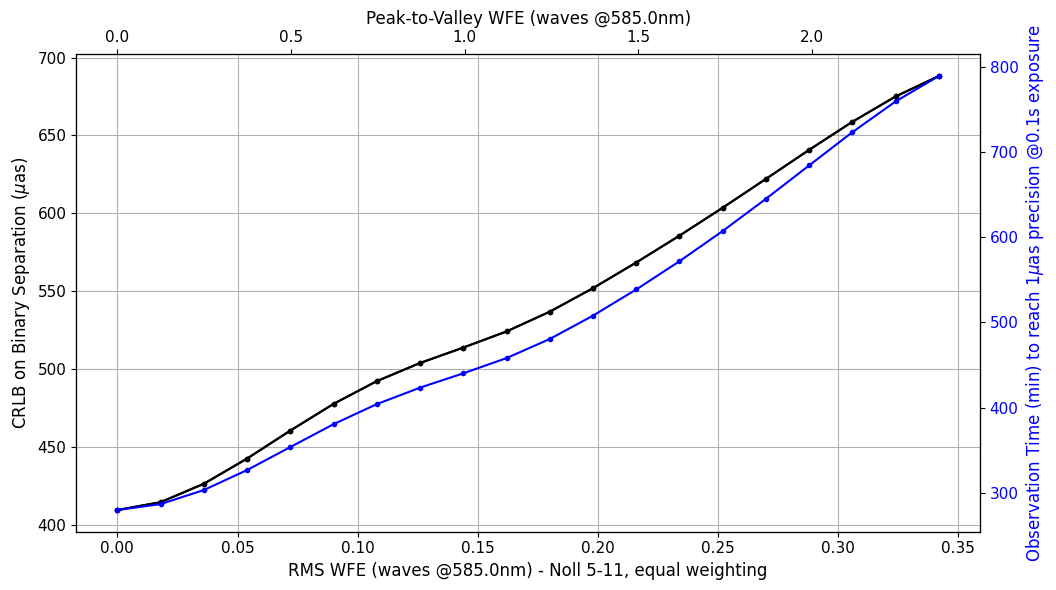

In [247]:
plt.figure(figsize=(10, 6))
plt.plot(
    RMS_WFE / (source.wavelengths[1] * 1e-9), jnp.array(CRLBS) * 1e6, "k.-"
)  # mas -> microarcseconds
plt.grid()
plt.xlabel(
    "RMS WFE (waves @{}nm) - Noll 5-11, equal weighting".format(source.wavelengths[1]),
    fontsize=12,
)
plt.gca().tick_params(axis="x", labelsize=11)
plt.gca().tick_params(axis="y", labelsize=11)
plt.ylabel("CRLB on Binary Separation (${\mu}$as)", fontsize=12)
ax1 = plt.gca()

ax2 = ax1.twiny()
ax2.plot(
    jnp.asarray(PVS) / (source.wavelengths[1] * 1e-9), jnp.array(CRLBS) * 1e6, "k.-"
)
ax2.set_xlabel(
    "Peak-to-Valley WFE (waves @{}nm)".format(source.wavelengths[1]),
    color="black",
    fontsize=12,
)
ax2.tick_params(axis="x", labelsize=11, labelcolor="black")
plt.tight_layout()


# total integration time
exp_time = 0.1  # s
N = ((jnp.array(CRLBS) * 1e6) / 1) ** 2
IT = N * exp_time * 1 / 60
ax3 = ax1.twinx()
ax3.plot(RMS_WFE / (source.wavelengths[1] * 1e-9), IT, "b.-")
ax3.tick_params(axis="y", labelsize=11, labelcolor="blue")
ax3.set_ylabel(
    "Observation Time (min) to reach 1$\mu$as precision @0.1s exposure",
    color="blue",
    fontsize=12,
)
# ax3.axhline(10, color="blue", linestyle="--")

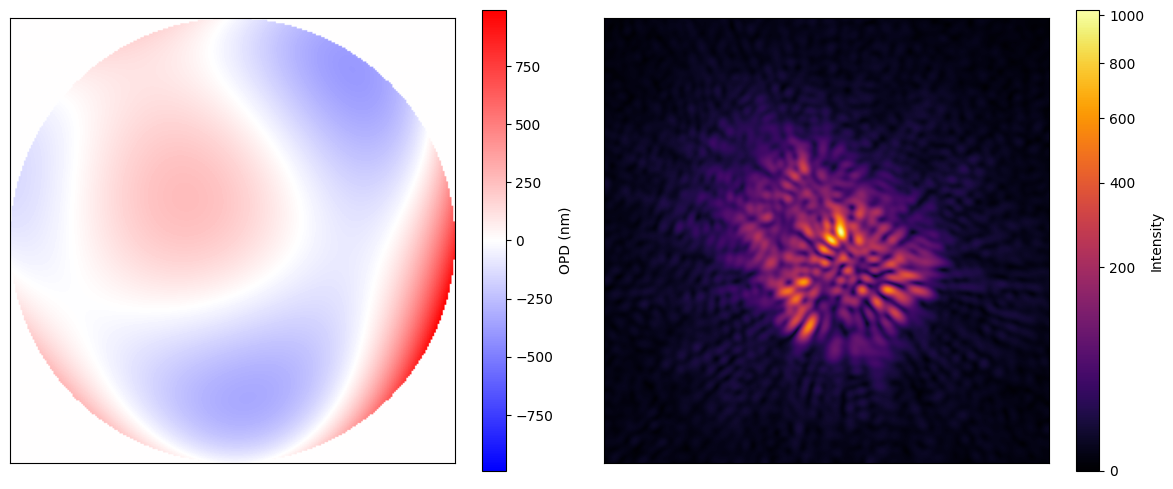

In [251]:
idx = -1
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(OPD_ARRS[idx] * 1e9, cmap="bwr", norm=CenteredNorm())
plt.colorbar(label="OPD (nm)")
plt.xticks([])
plt.yticks([])
plt.subplot(1, 2, 2)
plt.imshow(PSF_ARRS[idx], norm=PowerNorm(0.5), cmap="inferno")
plt.colorbar(label="Intensity")
plt.xticks([])
plt.yticks([])
plt.tight_layout()

In [236]:
RMS_WFE / (source.wavelengths[1] * 1e-9)

Array([0.        , 0.0179937 , 0.0359874 , 0.05398111, 0.07197481,
       0.08996851, 0.10796221, 0.12595592, 0.14394962, 0.16194332,
       0.17993702, 0.19793072, 0.21592443, 0.23391813, 0.25191183,
       0.26990553, 0.28789924, 0.30589294, 0.32388664, 0.34188034],      dtype=float64)